# NB03 — Phylogenetic Distribution and Bias Testing

Fisher's exact + BH-FDR phylum enrichment for each category. Pagel's λ using R subprocess. Dual-specialist scatter.

In [1]:
import sys, os, re, warnings, requests, json, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import fisher_exact, norm
from statsmodels.stats.multitest import fdrcorrection
warnings.filterwarnings("ignore")

spark = get_spark_session()
from pyspark.sql import functions as F

NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR  = NOTEBOOK_DIR.parent
DATA_DIR     = PROJECT_DIR / "data"
FIG_DIR      = PROJECT_DIR / "figures"
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

def is_valid_parquet(p):
    if not p.exists() or p.stat().st_size < 512:
        return False
    try:
        import pyarrow.parquet as pq; pq.read_schema(str(p)); return True
    except Exception:
        return False

def wilson_ci(n, N, alpha=0.05):
    if N == 0: return np.nan, np.nan
    p = n / N; z = norm.ppf(1 - alpha/2)
    denom = 1 + z**2/N
    centre = (p + z**2/(2*N)) / denom
    half = z * np.sqrt(p*(1-p)/N + z**2/(4*N**2)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)

def odds_ratio_ci(a, b, c, d, alpha=0.05):
    # Woolf logit OR with 95% CI
    a,b,c,d = a+0.5, b+0.5, c+0.5, d+0.5
    log_or = np.log(a*d/(b*c))
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    z = norm.ppf(1 - alpha/2)
    return np.exp(log_or), np.exp(log_or - z*se), np.exp(log_or + z*se)

print("Setup complete.")

Setup complete.


## Section 1 — Load Data

In [2]:
genome_counts = pd.read_parquet(DATA_DIR / "genome_metal_counts.parquet")
print(f"Loaded {len(genome_counts)} genomes")
print(genome_counts.head())

Loaded 27690 genomes
            genome_id                          species          phylum  \
0  GB_GCA_023387895.1         s__Gordonia alkanivorans  Actinomycetota   
1  GB_GCA_900444685.1         s__Achromobacter spanius  Pseudomonadota   
2  RS_GCF_001541345.2           s__Allorhizobium vitis  Pseudomonadota   
3  GB_GCA_018714445.1  s__Fimadaptatus faecigallinarum     Bacillota_A   
4  GB_GCA_020441065.1          s__JACKOY01 sp024233935   Spirochaetota   

                 class          order_rank              family          genus  \
0        Actinomycetia     Mycobacteriales    Mycobacteriaceae       Gordonia   
1  Gammaproteobacteria     Burkholderiales  Burkholderiaceae_C  Achromobacter   
2  Alphaproteobacteria         Rhizobiales        Rhizobiaceae  Allorhizobium   
3           Clostridia  Christensenellales              CAG-74   Fimadaptatus   
4          Leptospirae       Leptospirales     Leptonemataceae       JACKOY01   

   n_defense  n_metabolism  n_homeostasis  n_me

## Section 2 — Phylum Enrichment

Fisher's exact test for enrichment of each category in each phylum. Apply BH-FDR correction.

In [3]:
MAJOR_PHYLA = ['Actinomycetota', 'Pseudomonadota', 'Bacillota', 'Chloroflexota', 'Bacteroidota', 'Cyanobacteriota']
categories = ['defense', 'metabolism', 'homeostasis']

enrichment_rows = []
pvalues = []

for phylum in MAJOR_PHYLA:
    phylum_data = genome_counts[genome_counts['phylum'] == phylum]
    rest_data = genome_counts[genome_counts['phylum'] != phylum]
    
    for category in categories:
        col = f"n_{category}"
        
        # Contingency table: [phylum_has, phylum_not, rest_has, rest_not]
        phylum_has = (phylum_data[col] > 0).sum()
        phylum_not = (phylum_data[col] == 0).sum()
        rest_has = (rest_data[col] > 0).sum()
        rest_not = (rest_data[col] == 0).sum()
        
        oddsratio, pval = fisher_exact([[phylum_has, phylum_not], [rest_has, rest_not]], alternative='two-sided')
        or_est, or_ci_low, or_ci_high = odds_ratio_ci(phylum_has, phylum_not, rest_has, rest_not)
        
        enrichment_rows.append({
            'phylum': phylum,
            'category': category,
            'phylum_has': phylum_has,
            'phylum_not': phylum_not,
            'rest_has': rest_has,
            'rest_not': rest_not,
            'odds_ratio': or_est,
            'or_ci_low': or_ci_low,
            'or_ci_high': or_ci_high,
            'p_value': pval
        })
        pvalues.append(pval)

enrichment_df = pd.DataFrame(enrichment_rows)

# BH-FDR correction — fdrcorrection returns (reject, corrected_pvalues)
reject, q_values = fdrcorrection(enrichment_df['p_value'].values, alpha=0.05)
enrichment_df['q_value'] = q_values
enrichment_df['significant'] = reject

enrichment_df.to_csv(DATA_DIR / "phylum_enrichment.csv", index=False)

print("Significant enrichments (q < 0.05):")
sig = enrichment_df[enrichment_df['significant']]
if len(sig) > 0:
    print(sig[['phylum', 'category', 'odds_ratio', 'or_ci_low', 'or_ci_high', 'q_value']])
else:
    print("None")

Significant enrichments (q < 0.05):
             phylum     category  odds_ratio  or_ci_low   or_ci_high  \
0    Actinomycetota      defense    6.582090   3.191952    13.572857   
1    Actinomycetota   metabolism    1.609514   1.490584     1.737934   
2    Actinomycetota  homeostasis    1.544468   1.345258     1.773178   
3    Pseudomonadota      defense   31.653404  12.491729    80.208110   
4    Pseudomonadota   metabolism    2.921576   2.757640     3.095259   
5    Pseudomonadota  homeostasis   11.006814   9.076712    13.347339   
6         Bacillota      defense    0.653269   0.474988     0.898467   
7         Bacillota   metabolism    0.442271   0.403501     0.484766   
8         Bacillota  homeostasis    1.471241   1.249479     1.732362   
9     Chloroflexota      defense   13.068751   0.814705   209.636896   
11    Chloroflexota  homeostasis    1.432321   1.014769     2.021685   
12     Bacteroidota      defense  117.567688   7.338836  1883.426957   
13     Bacteroidota   metabo

## Section 3 — Forest Plot

Horizontal bar chart showing log2(OR) ± log2(CI) for each phylum per category.

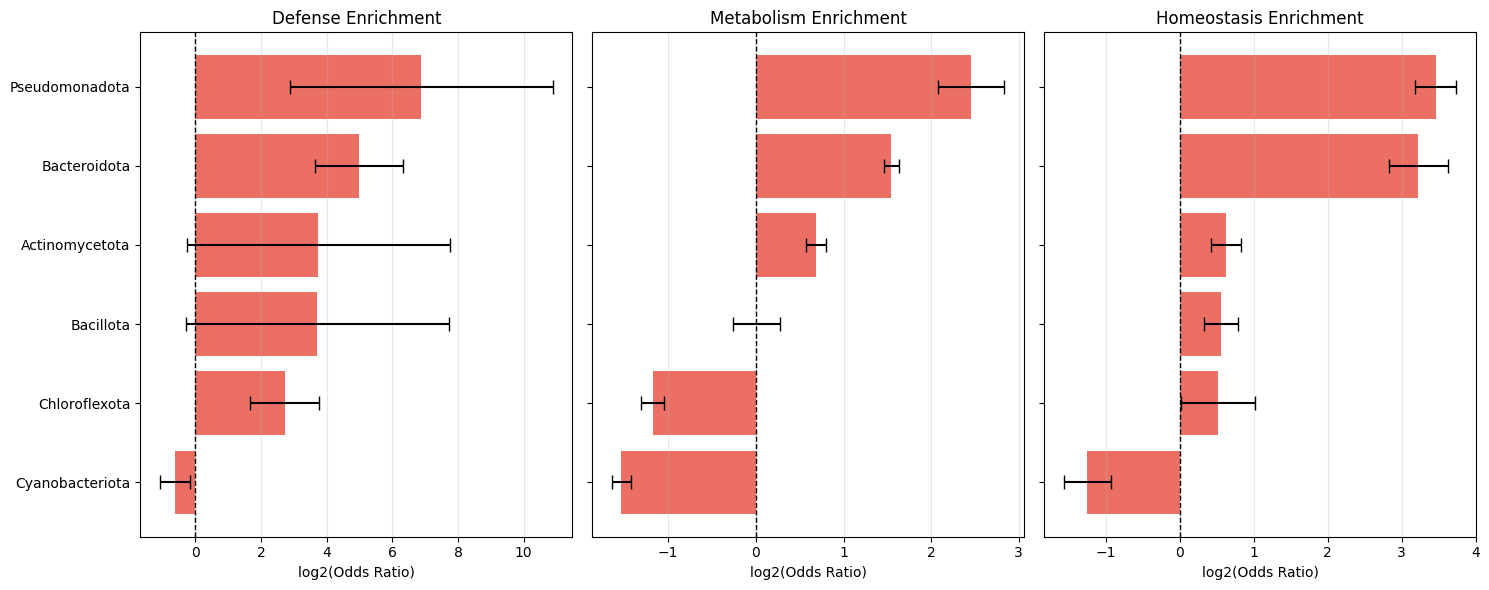

Figure saved: nb03_forest_phylum_enrichment.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for i, category in enumerate(['defense', 'metabolism', 'homeostasis']):
    cat_data = enrichment_df[enrichment_df['category'] == category].copy()
    cat_data = cat_data.sort_values('odds_ratio')
    
    ax = axes[i]
    
    y_pos = np.arange(len(cat_data))
    log2_or = np.log2(cat_data['odds_ratio'].values)
    log2_ci_low = np.log2(cat_data['or_ci_low'].values)
    log2_ci_high = np.log2(cat_data['or_ci_high'].values)
    
    errors = np.array([log2_or - log2_ci_low, log2_ci_high - log2_or])
    
    colors = ['#e74c3c' if q < 0.05 else '#bdc3c7' for q in cat_data['q_value'].values]
    
    ax.barh(y_pos, log2_or, xerr=errors, color=colors, capsize=5, alpha=0.8)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(cat_data['phylum'].values)
    ax.set_xlabel('log2(Odds Ratio)')
    ax.set_title(f"{category.capitalize()} Enrichment")
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "nb03_forest_phylum_enrichment.png", dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: nb03_forest_phylum_enrichment.png")

## Section 4 — Pagel's λ

Export species trait matrix and run phylogenetic signal test in R.

In [ ]:
from Bio import Phylo

# Load pruned species-labeled trees (produced by running the prune step below once;
# cached at DATA_DIR. Tips are bare GTDB species names, one per species.)
bac_tree_path = DATA_DIR / 'pruned_bac_species_tree.nwk'
arc_tree_path = DATA_DIR / 'pruned_arc_species_tree.nwk'

if not bac_tree_path.exists():
    # Prune full GTDB trees to the species in genome_counts (run once, saves ~1 min)
    GTDB_DIR = Path("/home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data")
    bac_all = Phylo.read(GTDB_DIR / 'gtdb_bac120_r214.tree', 'newick')
    arc_all = Phylo.read(GTDB_DIR / 'gtdb_ar53_r214.tree', 'newick')
    bac_tax = pd.read_csv(GTDB_DIR / 'gtdb_bac120_taxonomy_parsed.csv')
    arc_tax = pd.read_csv(GTDB_DIR / 'gtdb_ar53_taxonomy_parsed.csv')
    all_tax = pd.concat([bac_tax, arc_tax], ignore_index=True)
    # Build accession → species mapping
    acc_to_sp = dict(zip(all_tax['accession'], all_tax['gtdb_species']))
    for tree, path in [(bac_all, bac_tree_path), (arc_all, arc_tree_path)]:
        keep = {t.name for t in tree.get_terminals()} & set(acc_to_sp)
        for t in tree.get_terminals():
            if t.name not in keep:
                tree.prune(t)
        for t in tree.get_terminals():
            t.name = acc_to_sp.get(t.name, t.name)
        Phylo.write(tree, path, 'newick')
        print(f"Pruned tree: {len(tree.get_terminals())} tips → {path.name}")

bac_tips = {t.name for t in Phylo.read(bac_tree_path, 'newick').get_terminals()}
arc_tips = {t.name for t in Phylo.read(arc_tree_path, 'newick').get_terminals()}
all_tips  = bac_tips | arc_tips

# Species trait matrix; genome_counts already has one row per species
# genome_counts.species uses GTDB 's__' prefix; tree tips use bare names
gc = genome_counts.copy()
gc['sp'] = gc['species'].str.removeprefix('s__')

trait_cols = gc.groupby('sp')[['n_defense','n_metabolism','n_homeostasis']].max()
trait_cols = (trait_cols > 0).astype(int)
trait_cols.columns = ['has_defense', 'has_metabolism', 'has_homeostasis']

tax_cols = gc.groupby('sp')[['phylum', 'class', 'order_rank', 'family', 'genus']].first()
tax_cols = tax_cols.rename(columns={'class': 'klass', 'order_rank': 'order'})

species_traits = pd.concat([trait_cols, tax_cols], axis=1).reset_index().rename(columns={'sp': 'species'})
species_traits['domain'] = np.where(
    species_traits['species'].isin(bac_tips), 'Bacteria',
    np.where(species_traits['species'].isin(arc_tips), 'Archaea', None)
)
matched = species_traits.dropna(subset=['domain']).copy()
print(f"Species in tree: {len(matched):,}  "
      f"(Bacteria: {(matched['domain']=='Bacteria').sum():,}, "
      f"Archaea: {(matched['domain']=='Archaea').sum():,})")
print(f"Defense: {matched['has_defense'].mean():.1%}  "
      f"Metabolism: {matched['has_metabolism'].mean():.1%}  "
      f"Homeostasis: {matched['has_homeostasis'].mean():.1%}")


In [ ]:
LAMBDA_CSV  = DATA_DIR / 'pagel_lambda_summary.csv'
RSCRIPT     = Path('/home/hmacgregor/r_env/bin/Rscript')
LEVEL_COLS  = ['phylum', 'klass', 'order', 'family', 'genus']
LEVEL_NAMES = {'phylum': 'phylum', 'klass': 'class', 'order': 'order',
               'family': 'family', 'genus': 'genus'}

def write_trait_file(df, level_col, tree_tips, path):
    agg = (
        df[df['species'].isin(tree_tips) & df[level_col].notna()]
        .groupby(level_col, as_index=False)
        .agg(accession=('species', 'first'),
             has_defense    =('has_defense',    'max'),
             has_metabolism =('has_metabolism', 'max'),
             has_homeostasis=('has_homeostasis','max'))
        .rename(columns={level_col: 'taxon'})
    )
    agg.to_csv(path, index=False)
    return len(agg)

def run_pagel_r(tree_path, trait_csv, level, domain, timeout=300):
    r_code = f"""
suppressPackageStartupMessages({{ library(ape); library(phytools) }})
tree   <- read.tree("{tree_path}")
traits <- read.csv("{trait_csv}")
common <- intersect(tree$tip.label, traits$accession)
if (length(common) < 3) {{ q(save="no") }}
tree   <- keep.tip(tree, common)
idx    <- match(tree$tip.label, traits$accession)
tree$tip.label <- traits$taxon[idx]
rownames(traits) <- traits$taxon
if (!is.ultrametric(tree)) tree <- force.ultrametric(tree, method="extend")
for (tc in c("has_defense","has_metabolism","has_homeostasis")) {{
    tv <- setNames(as.numeric(traits[[tc]]), rownames(traits))
    if (length(unique(tv)) < 2) next
    sig <- tryCatch(phylosig(tree, tv, method="lambda", test=TRUE), error=function(e) NULL)
    if (is.null(sig)) next
    cat(paste0("{domain},{level},", tc, ",", round(sig$lambda,4), ",", format(sig$P, scientific=TRUE), "\\n"))
}}
"""
    res = subprocess.run([str(RSCRIPT), '-'], input=r_code, capture_output=True,
                         text=True, timeout=timeout)
    if res.returncode != 0:
        print(f"  R error [{domain}/{level}]: {res.stderr[:200]}")
    return res.stdout

if LAMBDA_CSV.exists():
    df_lambda = pd.read_csv(LAMBDA_CSV)
    print(f"Loaded cached Pagel's λ results ({len(df_lambda)} rows)")
else:
    DOMAINS = {'Bacteria': (bac_tree_path, bac_tips), 'Archaea': (arc_tree_path, arc_tips)}
    results  = []
    for domain, (tree_path, tips) in DOMAINS.items():
        dom_df = matched[matched['domain'] == domain].copy()
        for col in LEVEL_COLS:
            label = LEVEL_NAMES[col]
            trait_file = DATA_DIR / f'traits_{domain}_{col}.csv'
            n = write_trait_file(dom_df, col, tips, trait_file)
            print(f"  {domain}/{label}: {n} taxa", end=' ... ', flush=True)
            stdout = run_pagel_r(str(tree_path), str(trait_file), label, domain)
            for line in stdout.splitlines():
                parts = line.strip().split(',')
                if len(parts) == 5:
                    results.append({'domain': parts[0], 'level': parts[1], 'trait': parts[2],
                                    'lambda': float(parts[3]), 'p_value': float(parts[4])})
                    print(f"λ={parts[3]}", end='  ', flush=True)
            print()
    df_lambda = pd.DataFrame(results)
    df_lambda.to_csv(LAMBDA_CSV, index=False)
    print(f"\nSaved {len(df_lambda)} results → {LAMBDA_CSV.name}")


In [ ]:
LEVEL_ORDER = ['phylum', 'class', 'order', 'family', 'genus']
TRAIT_LABELS = {'has_defense': 'Defense', 'has_metabolism': 'Metabolism',
                'has_homeostasis': 'Homeostasis'}

df_plot = df_lambda.copy()
df_plot['level'] = pd.Categorical(df_lambda['level'], categories=LEVEL_ORDER, ordered=True)

sig = df_plot[df_plot['p_value'] < 0.05][['domain','level','trait','lambda','p_value']].sort_values(['domain','level'])
print("=== Significant Pagel's λ (p < 0.05) ===")
print(sig.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, domain in zip(axes, ['Bacteria', 'Archaea']):
    dom_df = df_plot[df_plot['domain'] == domain]
    pivot = dom_df.pivot(index='level', columns='trait', values='lambda').reindex(LEVEL_ORDER).rename(columns=TRAIT_LABELS)
    pvals = dom_df.pivot(index='level', columns='trait', values='p_value').reindex(LEVEL_ORDER).rename(columns=TRAIT_LABELS)
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r', center=0.5,
                vmin=0, vmax=1, mask=(pvals >= 0.05).fillna(True),
                linewidths=0.5, cbar_kws={'label': "λ"})
    ax.set_title(f"{domain} (grey = n.s.)", fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Taxonomic level')

plt.suptitle("Pagel's λ — Phylogenetic Signal in Metal Functional Traits", y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb03_lambda_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


## Section 5 — Dual-Specialist Scatter

Scatter plot of defense vs metabolism gene counts, colored by phylum.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

phylum_colors = {
    'Actinomycetota': '#e74c3c',
    'Pseudomonadota': '#3498db',
    'Bacillota': '#2ecc71',
    'Chloroflexota': '#f39c12',
    'Bacteroidota': '#9b59b6',
    'Cyanobacteriota': '#1abc9c'
}

for phylum in MAJOR_PHYLA:
    phylum_data = genome_counts[genome_counts['phylum'] == phylum]
    ax.scatter(phylum_data['n_defense'], phylum_data['n_metabolism'],
              label=phylum, alpha=0.6, s=30,
              color=phylum_colors.get(phylum, '#95a5a6'))

# Mark 75th percentile thresholds
p75_def = genome_counts['n_defense'].quantile(0.75)
p75_met = genome_counts['n_metabolism'].quantile(0.75)

ax.axvline(x=p75_def, color='gray', linestyle='--', alpha=0.5, label=f'75th %ile defense')
ax.axhline(y=p75_met, color='gray', linestyle='--', alpha=0.5, label=f'75th %ile metabolism')

# Count dual specialists (both > 75th percentile)
dual_spec = ((genome_counts['n_defense'] > p75_def) & (genome_counts['n_metabolism'] > p75_met)).sum()

ax.set_xlabel('Defense Gene Count')
ax.set_ylabel('Metabolism Gene Count')
ax.set_title('Dual-Specialist Genomes')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "nb03_dual_specialist_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Dual specialists (both > 75th percentile): {dual_spec}")
print(f"Total genomes: {len(genome_counts)}")
print(f"Figure saved: nb03_dual_specialist_scatter.png")

In [ ]:
# Broad co-occurrence breakdown (H3 — any-gene threshold, not 75th-pct)
n_total = len(genome_counts)
both_any     = ((genome_counts['n_defense'] > 0) & (genome_counts['n_metabolism'] > 0)).sum()
defense_only = ((genome_counts['n_defense'] > 0) & (genome_counts['n_metabolism'] == 0)).sum()
metab_only   = ((genome_counts['n_defense'] == 0) & (genome_counts['n_metabolism'] > 0)).sum()
neither      = ((genome_counts['n_defense'] == 0) & (genome_counts['n_metabolism'] == 0)).sum()

print("Broad co-occurrence (n_defense > 0 AND n_metabolism > 0):")
print(f"  Both classes:      {both_any:,}  ({both_any/n_total*100:.1f}%)")
print(f"  Defense only:      {defense_only:,}  ({defense_only/n_total*100:.1f}%)")
print(f"  Metabolism only:   {metab_only:,}  ({metab_only/n_total*100:.1f}%)")
print(f"  Neither:           {neither:,}  ({neither/n_total*100:.1f}%)")
print(f"  Sum check:         {both_any + defense_only + metab_only + neither:,} (should be {n_total:,})")